In [27]:
import casadi as cs
import numpy as np
from collections import deque
from matplotlib import pyplot as plt
from scipy.linalg import null_space
from time import time
from copy import deepcopy
from matplotlib import pyplot as plt

np.set_printoptions(precision=4, suppress=True, linewidth=125)

In [28]:
N_F = 25
N_S = 50
K = 40
W = cs.sqrt(10)
N_BRANCH = 10
N_STEPS = 400
N_NEWTON = 10
STEP_SIZE = 0.005
EPSILON = 0.05
U0 = np.array(
    # [-0.,1.1185,0. ,-0.,-0.,-0.,0.0197,0.0118,0.0195,0.,1.1185]
    [0.0, 1.01, 0.0, 0.0, 0.0, 0.0, 0.00565685, 0.01525397, 0.00565685, 0.0, 1.01]
    # [0, 1.02334, 0.690765, -2.66782, -9.36157e-28, -1.42652, 0.0198692, 0.00669208, 0.0198692, 3.1187e-14, 4.58196]
)
PERIODIC = True

In [29]:
A1 = cs.DM([[0,1,0,0,0,0],[0,0,0,0,1,0]])
A2 = cs.DM([[0,0,1,0,0,0],[0,0,0,1,0,0],[0,0,0,0,0,1]])
A3 = cs.DM([[1,0,0,0,0,0]])
Ap = A1
Aap = -A2 if PERIODIC else A2
Anp = A3

In [30]:
xs = cs.SX.sym("xs", 4)
xf = cs.SX.sym("xf", 6)
xi = cs.SX.sym("xi")
dt = cs.SX.sym("dt")

l = cs.sqrt(xs[0] ** 2 + xs[1] ** 2)
Es = 0.5 * (xs[2] ** 2 + xs[3] ** 2) + xs[1] + 0.5 * (l - 1) ** 2
Ef = 0.5 * (xf[3] ** 2 + xf[4] ** 2) + xf[1]
dxs = cs.vertcat(
    xs[2:], K * (1 - l) * xs[0] / l, K * (1 - l) * xs[1] / l - 1
) + xi * cs.gradient(Es, xs)
dxf = cs.vertcat(xf[3:], 0, -1, -(W**2) * xf[2]) + xi * cs.gradient(Ef, xf)

ff = cs.Function("ff", [xf, xi], [dxf])
fs = cs.Function("fs", [xs, xi], [dxs])
energy_flight = cs.Function("energy_flight", [xf], [Ef])
energy_stance = cs.Function("energy_stance", [xs], [Es])

k1s = fs(xs, xi)
k1f = ff(xf, xi)
k2s = fs(xs + dt / 2 * k1s, xi)
k2f = ff(xf + dt / 2 * k1f, xi)
k3s = fs(xs + dt / 2 * k2s, xi)
k3f = ff(xf + dt / 2 * k2f, xi)
k4s = fs(xs + dt * k3s, xi)
k4f = ff(xf + dt * k3f, xi)
xs_ = xs + dt / 6 * (k1s + 2 * k2s + 2 * k3s + k4s)
xf_ = xf + dt / 6 * (k1f + 2 * k2f + 2 * k3f + k4f)

s2f = cs.vertcat(
    xs[:2], cs.atan(-xs[0] / xs[1]), xs[2:], (xs[0] * xs[3] - xs[1] * xs[2]) / l
)
f2s = cs.vertcat(-cs.sin(xf[2]), cs.cos(xf[2]), xf[3:5])

stance_to_flight = cs.Function("stance_to_flight", [xs], [s2f])
flight_to_stance = cs.Function("flight_to_stance", [xf], [f2s])
RK4s = cs.Function("RK4s", [xs, dt, xi], [xs_])
RK4f = cs.Function("RK4f", [xf, dt, xi], [xf_])

traj_f = RK4f.fold(N_F)
traj_s = RK4s.fold(N_S)
traj_f_list = RK4f.mapaccum(N_F)
traj_s_list = RK4s.mapaccum(N_S)

In [31]:
x_init = cs.SX.sym("x_init", 6)
t = cs.SX.sym("t", 3)
E = cs.SX.sym("E")
du1 = cs.SX.sym("du1", 11)
du2 = cs.SX.sym("du2", 11)
phi = cs.SX.sym("phi", 10)

z = cs.vertcat(x_init, t, xi)
u = cs.vertcat(z, E)

x_TD = traj_f(x_init, t[0], xi)
x_LO = traj_s(flight_to_stance(x_TD), t[1], xi)
x_apex = traj_f(stance_to_flight(x_LO), t[2], xi)

root = cs.vertcat(
    Ap @ x_apex - A1 @ x_init,
    Aap @ x_apex + A2 @ x_init,
    Anp @ x_init,
    x_init[4],
    energy_flight(x_init) - E,
    cs.cos(x_TD[2]) - x_TD[1],
    x_LO[0] ** 2 + x_LO[1] ** 2 - 1,
)

J_root = cs.jacobian(root, z)
J_ext = cs.jacobian(root, u)
z_newton = z - cs.inv(J_root) @ root

b = du1.T @ cs.jtimes(J_ext, u, du2).T @ phi

newton_step = cs.Function("newton_step", [z, E], [z_newton])
compute_J = cs.Function("compute_J", [u], [J_ext])
compute_Jz = cs.Function("compute_Jz",[z,E],[J_root])
residual = cs.Function("residual", [u], [root])
hessian = cs.Function("Hessian", [u, du1, du2, phi], [b])

newton = newton_step.fold(N_NEWTON)

In [32]:
opti = cs.Opti()
opti.solver(
    "ipopt", {"print_time": 0, "ipopt.print_level": 0, "ipopt.tol": 1e-12}
)

opti_u = opti.variable(11)
opti.subject_to(residual(opti_u) == 0)

In [33]:
def u2traj(u):
    x0,dt,xi = u[:6],u[6:9],u[9]
    traj1 = traj_f_list(x0, dt[0], xi)
    traj2 = stance_to_flight(
        traj_s_list(flight_to_stance(traj1[:, -1]), dt[1], xi)
    )
    traj3 = traj_f_list(traj2[:, -1], dt[2], xi)
    traj1[0, :] += traj2[0, 0] - traj1[0, -1]
    traj3[0, :] += traj2[0, -1] - traj3[0, 0]
    traj = cs.horzcat(traj1, traj2, traj3)
    return np.array(traj)

def process_bifurcation(u, p1):
    J = compute_J(u)
    val, vec = np.linalg.eig(cs.vertcat(J, p1.T))
    idx_val = np.argmin(np.abs(val))
    p2 = vec[:, idx_val].real.reshape((11,1))
    p2 =  p2 - np.dot(p1.T,p2) * p1 
    p2 = p2 / np.linalg.norm(p2)
    val, vec = np.linalg.eig(J @ J.T)
    idx_val = np.argmin(np.abs(val))
    e = vec[:, idx_val].real
    b12 = hessian(u, p1, p2, e)
    b22 = hessian(u, p2, p2, e)
    beta2 = 1
    beta1 = -b22 / (2 * b12)
    p2 = beta1 * p1 + beta2 * p2
    p2 = p2 / np.linalg.norm(p2)
    return np.array(p2)

In [34]:
def naive_exploration(u,STEP_SIZE,N_STEPS):
    M = []
    p_stored = None 
    det_stored = None
    for i in range(N_STEPS):
        # corrector step
        opti.set_initial(opti_u,u)
        opti.solve()
        u = deepcopy(opti.value(u))

        # predictor step
        J = compute_J(u)
        p = null_space(J)
        det = np.linalg.det(cs.vertcat(J,p.T))
        if det < 0:
            # set p to the forward direction
            p = - p
        if i>=2:
            if p_stored.T @ p < 0 :
                coeff = det_stored / (det_stored + np.abs(det))
                u_star = coeff * M[-1] + (1-coeff) * M[-2]
                p1 = coeff * p - (1-coeff) * p_stored
                print(det_stored,det,coeff)
                print(p1.T)
                print(u_star)
                break
        u += -1 * STEP_SIZE * p.reshape((11,))
        M.append(u)
        p_stored = p.copy()
        det_stored = np.abs(det)

    return M



# opti.set_initial(opti_u,U0)
# opti.solve()
# U0 = opti.value(opti_u)
# M = naive_exploration(U0,0.005,100)
# print([m_[1] for m_ in M])

In [35]:
def find_regular_point(BP):
    u_star, p1, p2 = BP
    u1 = u_star + 0.05 * p1.reshape((11,))
    u2 = u_star + 0.05 * p2.reshape((11,))
    return u1,u2 

In [36]:
def compute_generator(u0,STEP_SIZE,N_STEPS):

    M,BP,TP,IP = [],[],[],[]
    p_stored = None
    det_stored = None
    u = u0.copy()
    M.append(u0)
    d = 1
    step = 0

    while step<N_STEPS:

        # predictor step
        J = compute_J(u)
        p = null_space(J)
        det = np.linalg.det(cs.vertcat(J,p.T))
        if det < 0:
            # set p to the forward direction
            p = - p
        u += d * STEP_SIZE * p.reshape((11,))

        # corrector step
        opti.set_initial(opti_u,u)
        opti.solve()
        u = deepcopy(opti.value(opti_u))
        

        isSpecialPoint = True
        if u[1] <= 1.01 and np.abs(u[3]) <= 1e-6: 
            print("infeasible")
            IP.append(deepcopy(M[-1]))
        elif step >= 2 and (p_stored.T @ p) < 0:
            print("bifurcation")
            coeff = det_stored / (det_stored + np.abs(det))
            u_star = coeff * M[-1] + (1-coeff) * M[-2]
            p1 = coeff * p - (1-coeff) * p_stored
            p1 = p1/np.linalg.norm(p1)
            p2 = process_bifurcation(u_star, p1)
            BP.append((u_star,(M[-2] - M[-1])/np.linalg.norm(M[-2] - M[-1]),p2))
        elif step>2 and np.linalg.det(compute_Jz(u[:10],u[10]))*np.linalg.det(compute_Jz(M[-1][:10],M[-1][10])) < 0:
            print("turning point")
            TP.append((u,p))
        else:
            isSpecialPoint = False 

        step += 1
        M.append(u)
        p_stored = p.copy()
        det_stored = np.abs(det)

        if isSpecialPoint:
            if d==1:
                step = 0
                d=-1
                u = u0.copy()
            else:
                break

    return M,BP,IP,TP


# opti.set_initial(opti_u,U0)
# opti.solve()
# U0 = opti.value(opti_u)
# M,BP,IP,TP = compute_generator(U0,0.01,200)
# u_star_1, u_star_2 = find_regular_point(BP[0])

# M,BP,IP,TP = compute_generator(u_star_1,0.01,200)
# u_star_1, u_star_2 = find_regular_point(BP[0])
# M,BP,IP,TP = compute_generator(u_star_1,0.01,200)
# print(BP)

In [37]:
opti.set_initial(opti_u,U0)
opti.solve()
U0 = opti.value(opti_u)
to_explore = deque([U0])
explored = []
connected_component = []
idx_branch = 0

while to_explore and idx_branch < N_BRANCH: 
    print(idx_branch)
    u_star = to_explore.popleft()
    M,BP,IP,TP = compute_generator(u_star,STEP_SIZE,N_STEPS)
    # print(BP)

    for bifurcation_point in BP:
        new = True
        for special_point in explored:
            if np.linalg.norm(bifurcation_point[0] - special_point) < EPSILON: 
                new = False
        if new: 
            explored.append(bifurcation_point[0])
            u1,u2 = find_regular_point(bifurcation_point)
            to_explore.append(u1)
            to_explore.append(u2)

    for turning_point in TP:
            new = True
            for special_point in explored:
                if np.linalg.norm(turning_point[0] - special_point) < EPSILON: 
                    new = False
            if new: 
                explored.append(turning_point[0])
                # u0 = continue_turning_point(turning_point)
                # to_explore.append(u0)
    

    connected_component.append(M)
    # explored.append(u_star)
    idx_branch += 1


0
infeasible
bifurcation
1
bifurcation
bifurcation
2
turning point
3
bifurcation
bifurcation
4
5
bifurcation
bifurcation
6
turning point
7
bifurcation
8


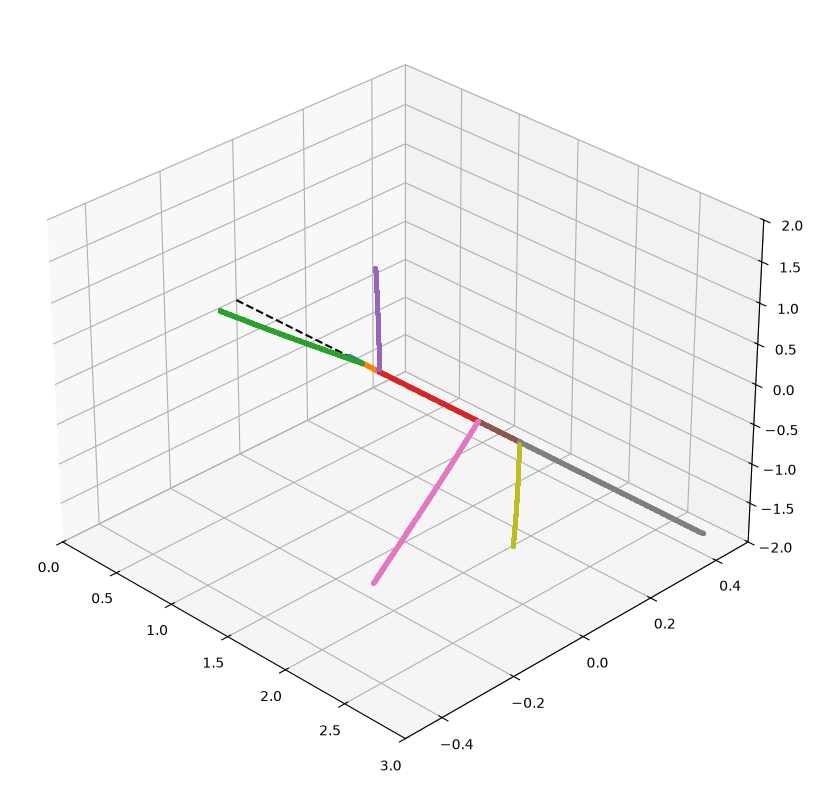

In [39]:
def plot_traj(ax,traj,c):
    ax.plot(traj[1,:],traj[2,:],traj[3,:], linewidth=0.5,color=c)

fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(1,1,1,projection="3d")
ax.plot([0.,3.],[0,0],[0,0],'k--')
for M in connected_component:
    traj = np.array(M)
    ax.plot(traj[:,1],traj[:,2],traj[:,3],'.',ms=5)
# for _u in M:
#     plot_traj(ax,u2traj(_u),'red')
# plt.plot([u_m[-1] for u_m in M],np.sign(dh))
ax.set_xlim(0,3)
ax.set_ylim(-0.5,0.5)
ax.set_zlim(-2,2)
ax.view_init(elev=30, azim=-45, roll=0)
plt.show()